In [1]:
import numpy as np 
import pandas as pd 
import datetime
import re
import os, os.path
import time
from sklearn.model_selection import train_test_split
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

2024-05-04 19:55:48.031598: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-04 19:55:48.066280: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-04 19:55:48.067192: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-04 19:55:48.674030: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
training_data_path = './out_4May2024/training/'
testing_data_path = './out_4May2024/testing/'
BUFFER_SIZE = 130

In [3]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  """Plots the confusion matrix."""
  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
    print('Confusion matrix, without normalization')

  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=55)
  plt.yticks(tick_marks, classes)
  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
              horizontalalignment="center",
              color="white" if cm[i, j] > thresh else "black")

  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.tight_layout()

## Train set

In [4]:
os.chdir(training_data_path)

In [5]:
gest_id = {'curl': 0, 'front_raise': 1, 'shoulder_press': 2, 'non_exersice': 3, "hammer_curl": 4}
class_names = list(gest_id.keys())

In [6]:
folders = ["curl","front_raise", "shoulder_press", "non_exersice", "hammer_curl"]
files =[]
completedf = pd.DataFrame(columns=['gesture','acceleration'])
for idx1,folder in enumerate(folders):
    files = os.listdir(folder)
    for idx2,file in enumerate(files):
        df_temp = pd.read_csv(folder+'/'+file)
        #print(df_temp[['Acc_X','Acc_Y','Acc_Z','Gyro_X', 'Gyro_Y', 'Gyro_Z']].to_numpy())
        print(file)
        x=df_temp[['ax','ay','az', 'q0', 'q1', 'q2', 'q3']].to_numpy()
        series = pd.Series(data={'gesture': folder, 'acceleration':x.tolist()})
        df_temp2= pd.DataFrame([series])
        completedf=pd.concat([completedf,df_temp2], ignore_index=True)


completedf['gesture'] = completedf['gesture'].apply(lambda x: gest_id[x])
#completedf['gesture'] = completedf['gesture'].apply(lambda x: gest_id[x])
#pad_val_df['gesture'] = pad_val_df['gesture'].apply(lambda x: gest_id[x])

completedf.to_csv('complete_data.csv', index=False)

curl.120.csv
curl.27.csv
curl.89.csv
curl.58.csv
curl.79.csv
curl.141.csv
curl.12.csv
curl.66.csv
curl.147.csv
curl.78.csv
curl.71.csv
curl.135.csv
curl.20.csv
curl.17.csv
curl.122.csv
curl.24.csv
curl.9.csv
curl.128.csv
curl.144.csv
curl.100.csv
curl.2.csv
curl.124.csv
curl.35.csv
curl.64.csv
curl.73.csv
curl.82.csv
curl.125.csv
curl.115.csv
curl.54.csv
curl.118.csv
curl.129.csv
curl.7.csv
curl.11.csv
curl.0.csv
curl.139.csv
curl.81.csv
curl.142.csv
curl.133.csv
curl.150.csv
curl.6.csv
curl.8.csv
curl.22.csv
curl.21.csv
curl.18.csv
curl.104.csv
curl.134.csv
curl.75.csv
curl.112.csv
curl.47.csv
curl.57.csv
curl.132.csv
curl.143.csv
curl.69.csv
curl.30.csv
curl.114.csv
curl.88.csv
curl.32.csv
curl.34.csv
curl.93.csv
curl.65.csv
curl.14.csv
curl.80.csv
curl.86.csv
curl.111.csv
curl.97.csv
curl.84.csv
curl.110.csv
curl.101.csv
curl.51.csv
curl.140.csv
curl.102.csv
curl.119.csv
curl.95.csv
curl.108.csv
curl.145.csv
curl.137.csv
curl.107.csv
curl.121.csv
curl.94.csv
curl.4.csv
curl.130.csv


### Reshaping

In [7]:
def pad(data, seq_length, dim):
    """Get neighbour padding."""
    noise_level = 1
    padded_data = []
    # Before- Neighbour padding
    tmp_data = (np.random.rand(seq_length, dim) - 0.5) * noise_level + data[0]
    tmp_data[(seq_length -
              min(len(data), seq_length)):] = data[:min(len(data), seq_length)]
    padded_data.append(tmp_data)
    # After- Neighbour padding
    tmp_data = (np.random.rand(seq_length, dim) - 0.5) * noise_level + data[-1]
    tmp_data[:min(len(data), seq_length)] = data[:min(len(data), seq_length)]
    padded_data.append(tmp_data)
    return padded_data

In [8]:
proc_acc = completedf['acceleration'].to_numpy()

lensum=0
for gest in proc_acc:
    lensum+=len(gest)  
print(lensum/len(proc_acc))
print(len(proc_acc))
print(proc_acc)

500.0
778


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [9]:
pad_train_df = pd.DataFrame(columns=['gesture','acceleration'])
for idx4, proacc in enumerate(proc_acc):
    #print(proacc)
    #break
    pad_acc = pad(proacc,BUFFER_SIZE,7)

    for half in pad_acc:

        padSeries = pd.Series(data={'gesture': completedf['gesture'][idx4],
                                      'acceleration': half.tolist()})
        paddf_temp=pd.DataFrame([padSeries])
        pad_train_df=pd.concat([pad_train_df,paddf_temp], ignore_index=True)
    

In [10]:
len(pad_train_df.iloc[0]['acceleration'])

130

In [11]:
pad_train_df.to_csv('train_set_' + str(BUFFER_SIZE) + '.csv', index=False)

## Test and val set

In [12]:
os.chdir('../../'+testing_data_path)

In [13]:
folders = ["curl","front_raise", "shoulder_press", "non_exersice", "hammer_curl"]
files =[]
completedf = pd.DataFrame(columns=['gesture','acceleration'])
for idx1,folder in enumerate(folders):
    files = os.listdir(folder)
    for idx2,file in enumerate(files):
        df_temp = pd.read_csv(folder+'/'+file)
        #print(df_temp[['Acc_X','Acc_Y','Acc_Z','Gyro_X', 'Gyro_Y', 'Gyro_Z']].to_numpy())
        print(file)
        x=df_temp[['ax','ay','az', 'q0', 'q1', 'q2', 'q3']].to_numpy()
        series = pd.Series(data={'gesture': folder, 'acceleration':x.tolist()})
        df_temp2= pd.DataFrame([series])
        completedf=pd.concat([completedf,df_temp2], ignore_index=True)
completedf['gesture'] = completedf['gesture'].apply(lambda x: gest_id[x])
#completedf['gesture'] = completedf['gesture'].apply(lambda x: gest_id[x])
#pad_val_df['gesture'] = pad_val_df['gesture'].apply(lambda x: gest_id[x])

completedf.to_csv('complete_data.csv', index=False)

curl.106.csv
curl.50.csv
curl.31.csv
curl.99.csv
curl.40.csv
curl.29.csv
curl.109.csv
curl.52.csv
curl.16.csv
curl.90.csv
curl.36.csv
curl.55.csv
curl.96.csv
curl.113.csv
curl.45.csv
curl.59.csv
curl.39.csv
curl.44.csv
curl.43.csv
curl.28.csv
curl.33.csv
curl.77.csv
curl.148.csv
curl.136.csv
curl.87.csv
curl.92.csv
curl.53.csv
curl.138.csv
curl.56.csv
curl.26.csv
curl.3.csv
front_raise.9.csv
front_raise.123.csv
front_raise.22.csv
front_raise.109.csv
front_raise.113.csv
front_raise.2.csv
front_raise.163.csv
front_raise.20.csv
front_raise.28.csv
front_raise.67.csv
front_raise.42.csv
front_raise.75.csv
front_raise.120.csv
front_raise.94.csv
front_raise.133.csv
front_raise.25.csv
front_raise.45.csv
front_raise.43.csv
front_raise.69.csv
front_raise.114.csv
front_raise.71.csv
front_raise.62.csv
front_raise.34.csv
front_raise.116.csv
front_raise.87.csv
front_raise.41.csv
front_raise.162.csv
shoulder_press.11.csv
shoulder_press.63.csv
shoulder_press.15.csv
shoulder_press.39.csv
shoulder_press.

In [14]:
validation_ratio = 0.75
test_ratio = 0.25

val_set, test_set = train_test_split(completedf, test_size=1 - validation_ratio, random_state=0)

val_set.to_csv('val_set.csv', index=False)
test_set.to_csv('test_set.csv', index=False)

In [15]:
val_set = pd.read_csv('val_set.csv',converters={'acceleration': eval})
test_set = pd.read_csv('test_set.csv',converters={'acceleration': eval})

### Val

In [16]:
proc_acc = val_set['acceleration'].to_numpy()

lensum=0
for gest in proc_acc:
    lensum+=len(gest)  
print(lensum/len(proc_acc))
print(len(proc_acc))
print(proc_acc)

500.0
145


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [17]:
pad_val_df = pd.DataFrame(columns=['gesture','acceleration'])
for idx4, proacc in enumerate(proc_acc):
    #print(proacc)
    #break
    pad_acc = pad(proacc,BUFFER_SIZE,7)

    for half in pad_acc:

        padSeries = pd.Series(data={'gesture': val_set['gesture'][idx4],
                                      'acceleration': half.tolist()})
        paddf_temp=pd.DataFrame([padSeries])
        pad_val_df=pd.concat([pad_val_df,paddf_temp], ignore_index=True)
    

In [18]:
len(pad_val_df.iloc[0]['acceleration'])

130

In [19]:
pad_val_df.to_csv('val_set_' + str(BUFFER_SIZE) + '.csv', index=False)

### Test

In [20]:
proc_acc = test_set['acceleration'].to_numpy()

lensum=0
for gest in proc_acc:
    lensum+=len(gest)  
print(lensum/len(proc_acc))
print(len(proc_acc))
print(proc_acc)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [21]:
pad_test_df = pd.DataFrame(columns=['gesture','acceleration'])
for idx4, proacc in enumerate(proc_acc):
    #print(proacc)
    #break
    pad_acc = pad(proacc,BUFFER_SIZE,7)

    for half in pad_acc:

        padSeries = pd.Series(data={'gesture': test_set['gesture'][idx4],
                                      'acceleration': half.tolist()})
        paddf_temp=pd.DataFrame([padSeries])
        pad_test_df=pd.concat([pad_test_df,paddf_temp], ignore_index=True)
    

In [22]:
len(pad_test_df.iloc[0]['acceleration'])

130

In [23]:
pad_test_df.to_csv('test_set_' + str(BUFFER_SIZE) + '.csv', index=False)

## Train model

In [24]:
os.chdir('../../')

In [25]:
def reshape_function(data, label):
    reshaped_data = tf.reshape(data, [-1, 7, 1])
    return reshaped_data, label

In [26]:
train_set = pd.read_csv(training_data_path + 'train_set_' + str(BUFFER_SIZE) + '.csv',converters={'acceleration': eval})
test_set = pd.read_csv(testing_data_path + 'test_set_' + str(BUFFER_SIZE) + '.csv',converters={'acceleration': eval})
val_set = pd.read_csv(testing_data_path + 'val_set_' + str(BUFFER_SIZE) + '.csv',converters={'acceleration': eval})

In [27]:
samples = len(train_set['acceleration'][0])
print(samples)

cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(8, (4, 3),padding="same",activation="relu",
                           input_shape=(samples, 7, 1)),  # output_shape=(batch, 760, 3, 8)
    tf.keras.layers.MaxPool2D((6, 3)),  # (batch, 126, 1, 8)
    tf.keras.layers.Dropout(0.1),  # (batch, 126, 1, 8)
    tf.keras.layers.Conv2D(16, (4, 1), padding="same",activation="relu"), # (batch, 126, 1, 16)
    tf.keras.layers.MaxPool2D((6, 1), padding="same"),  # (batch, 21, 1, 16)
    tf.keras.layers.Dropout(0.1),  # (batch, 21, 1, 16)
    tf.keras.layers.Flatten(),  # (batch, 336)
    tf.keras.layers.Dense(16, activation="relu"),  # (batch, 16)
    tf.keras.layers.Dropout(0.1),  # (batch, 16)
    tf.keras.layers.Dense(5, activation="softmax")  # (batch, 4)
])

130


2024-05-04 19:56:52.736112: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-05-04 19:56:52.766547: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [28]:
tensor_train_set = tf.data.Dataset.from_tensor_slices(
    (np.array(train_set['acceleration'].tolist(),dtype=np.float64),
     train_set['gesture'].tolist()))

tensor_test_set = tf.data.Dataset.from_tensor_slices(
    (np.array(test_set['acceleration'].tolist(),dtype=np.float64),
     test_set['gesture'].tolist()))

tensor_val_set = tf.data.Dataset.from_tensor_slices(
    (np.array(val_set['acceleration'].tolist(),dtype=np.float64),
     val_set['gesture'].tolist()))

In [29]:
#calculate_model_size(lstm_model)
epochs_cnn = 30
batch_size = 8


#calculate_model_size(cnn_model3)
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

In [30]:
tensor_train_set_cnn = tensor_train_set.map(reshape_function)
tensor_test_set_cnn = tensor_test_set.map(reshape_function)
tensor_val_set_cnn = tensor_val_set.map(reshape_function)

In [31]:
tensor_train_set_cnn = tensor_train_set_cnn.batch(batch_size).repeat()
tensor_test_set_cnn = tensor_test_set_cnn.batch(batch_size)
tensor_val_set_cnn = tensor_val_set_cnn.batch(batch_size)

In [32]:
history = cnn_model.fit(
    tensor_train_set_cnn,
    epochs=epochs_cnn,
    validation_data=tensor_val_set_cnn,
    steps_per_epoch=300,
    ) #validation_steps=int((len(val_set) - 1) / batch_size2 + 1)

Epoch 1/30
300/300 [==============================] - 1s 2ms/step - loss: 1.5070 - accuracy: 0.4416 - val_loss: 1.4406 - val_accuracy: 0.5931
Epoch 2/30
300/300 [==============================] - 1s 2ms/step - loss: 1.1381 - accuracy: 0.5828 - val_loss: 1.1532 - val_accuracy: 0.6483
Epoch 3/30
300/300 [==============================] - 1s 2ms/step - loss: 1.0784 - accuracy: 0.6427 - val_loss: 0.9747 - val_accuracy: 0.6690
Epoch 4/30
300/300 [==============================] - 1s 2ms/step - loss: 0.9247 - accuracy: 0.6459 - val_loss: 1.0133 - val_accuracy: 0.6828
Epoch 5/30
300/300 [==============================] - 1s 2ms/step - loss: 0.8092 - accuracy: 0.7183 - val_loss: 0.7987 - val_accuracy: 0.6621
Epoch 6/30
300/300 [==============================] - 1s 2ms/step - loss: 0.8143 - accuracy: 0.7040 - val_loss: 1.2573 - val_accuracy: 0.3793
Epoch 7/30
300/300 [==============================] - 1s 2ms/step - loss: 0.6626 - accuracy: 0.7834 - val_loss: 0.7103 - val_accuracy: 0.7724
Epoch 

### Test metrics

In [33]:
loss_cnn, acc_cnn = cnn_model.evaluate(tensor_test_set_cnn)
pred_cnn = np.argmax(cnn_model.predict(tensor_test_set_cnn), axis=1)

id_to_gest = {v: k for k, v in gest_id.items()}
y_pred_label = [id_to_gest[i] for i in pred_cnn]

confusion_cnn = tf.math.confusion_matrix(
    labels=tf.constant(test_set['gesture'].to_numpy()),
    predictions=tf.constant(pred_cnn),
    num_classes=5)

print(confusion_cnn)
print("Loss {}, Accuracy {}".format(loss_cnn, acc_cnn))

13/13 [==============================] - 0s 824us/step
tf.Tensor(
[[10  0  0  6  0]
 [ 0 12  0  0  0]
 [ 0  0 10  0  0]
 [ 0  0  0 44  0]
 [ 0  0  0  2 14]], shape=(5, 5), dtype=int32)
Loss 0.26184120774269104, Accuracy 0.918367326259613



Classification Report:
                 precision    recall  f1-score   support

          curl       1.00      0.62      0.77        16
   front_raise       1.00      1.00      1.00        12
   hammer_curl       1.00      0.88      0.93        16
  non_exersice       0.85      1.00      0.92        44
shoulder_press       1.00      1.00      1.00        10

      accuracy                           0.92        98
     macro avg       0.97      0.90      0.92        98
  weighted avg       0.93      0.92      0.91        98



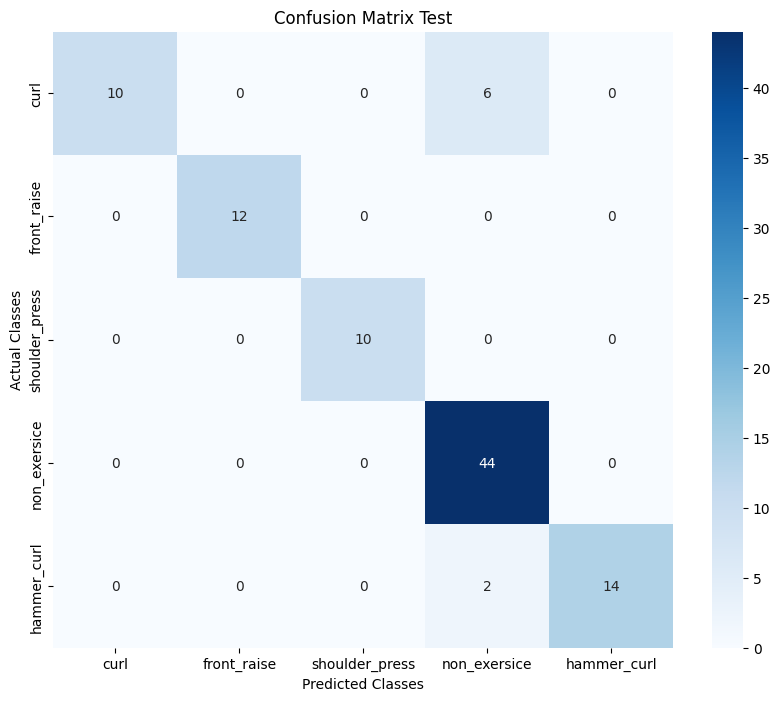

In [34]:
import seaborn as sns
confusion_cnn_np = confusion_cnn.numpy()
true_labels = test_set['gesture'].to_numpy()
true_labels = [id_to_gest[i] for i in true_labels]
print('\nClassification Report:\n', classification_report(true_labels, y_pred_label))
# Визуализация матрицы ошибок
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_cnn_np, annot=True, fmt="d", cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix Test')
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show()

### Val metrics

In [35]:
loss_cnn, acc_cnn = cnn_model.evaluate(tensor_val_set_cnn)
pred_cnn = np.argmax(cnn_model.predict(tensor_val_set_cnn), axis=1)

id_to_gest = {v: k for k, v in gest_id.items()}
y_pred_label = [id_to_gest[i] for i in pred_cnn]

confusion_cnn = tf.math.confusion_matrix(
    labels=tf.constant(val_set['gesture'].to_numpy()),
    predictions=tf.constant(pred_cnn),
    num_classes=5)

print(confusion_cnn)
print("Loss {}, Accuracy {}".format(loss_cnn, acc_cnn))

37/37 [==============================] - 0s 992us/step
tf.Tensor(
[[ 32   0   0  14   0]
 [  0  42   0   0   0]
 [  0   0  32   2   0]
 [  2   2   0 144   0]
 [  0   0   0   0  20]], shape=(5, 5), dtype=int32)
Loss 0.2478771060705185, Accuracy 0.931034505367279



Classification Report:
                 precision    recall  f1-score   support

          curl       0.94      0.70      0.80        46
   front_raise       0.95      1.00      0.98        42
   hammer_curl       1.00      1.00      1.00        20
  non_exersice       0.90      0.97      0.94       148
shoulder_press       1.00      0.94      0.97        34

      accuracy                           0.93       290
     macro avg       0.96      0.92      0.94       290
  weighted avg       0.93      0.93      0.93       290



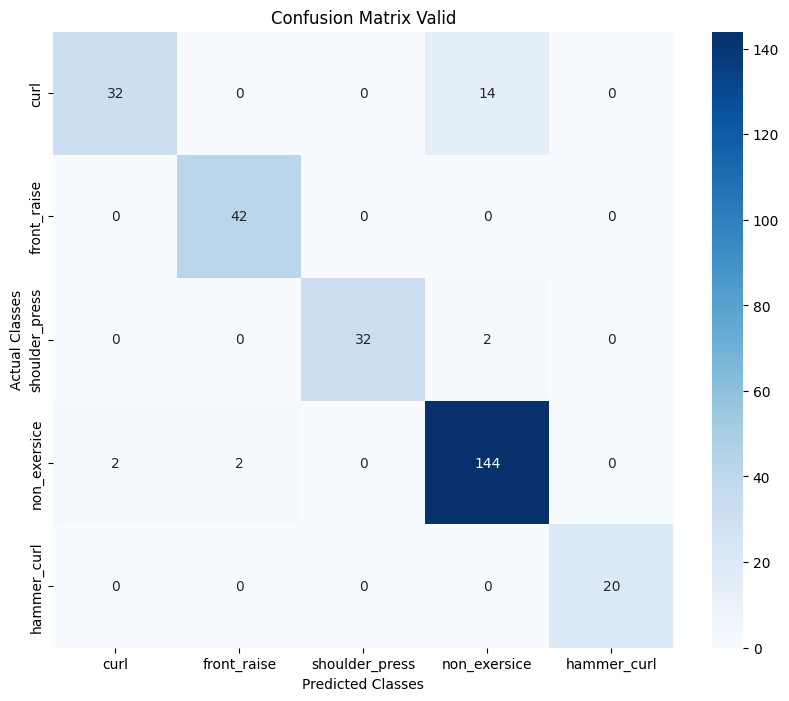

In [36]:
import seaborn as sns
confusion_cnn_np = confusion_cnn.numpy()
true_labels = val_set['gesture'].to_numpy()
true_labels = [id_to_gest[i] for i in true_labels]
print('\nClassification Report:\n', classification_report(true_labels, y_pred_label))
# Визуализация матрицы ошибок
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_cnn_np, annot=True, fmt="d", cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix Valid')
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show()

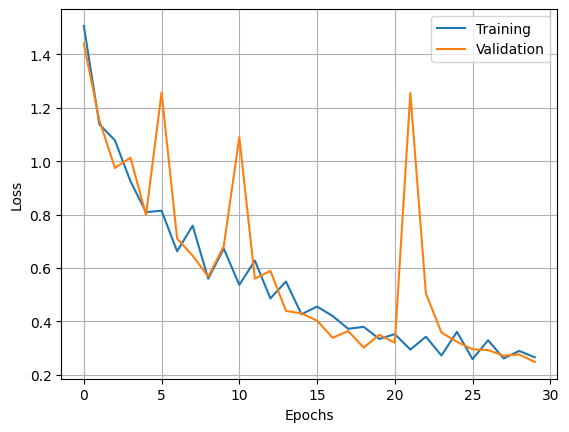

In [37]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'],loc='upper right')
plt.grid()


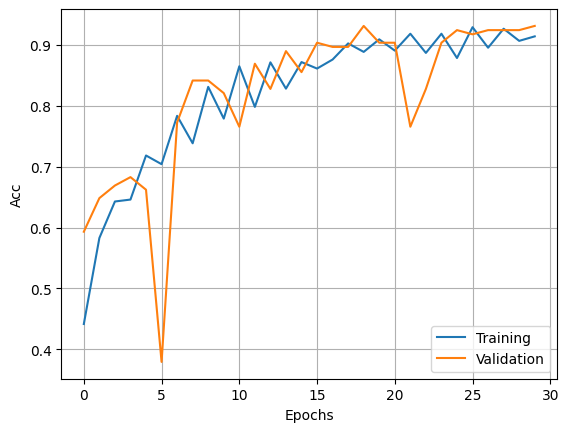

In [38]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel('Epochs')
plt.ylabel('Acc')
plt.legend(['Training','Validation',],loc='lower right')
plt.grid()


In [39]:
cnn_model.save('cnn_model3_half_gestures_' + str(BUFFER_SIZE) + '_04.05.2024.h5') 

/home/svs/anaconda3/envs/YOLO/lib/python3.9/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [40]:
converter = tf.lite.TFLiteConverter.from_keras_model(cnn_model)
cnn_tflite_model = converter.convert()

open("cnn_model3_half_" + str(BUFFER_SIZE) + "_04.05.2024.tflite", "wb").write(cnn_tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpxchwv_k7/assets


INFO:tensorflow:Assets written to: /tmp/tmpxchwv_k7/assets
2024-05-04 19:57:28.687221: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2024-05-04 19:57:28.687243: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2024-05-04 19:57:28.687468: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmpxchwv_k7
2024-05-04 19:57:28.688362: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2024-05-04 19:57:28.688373: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /tmp/tmpxchwv_k7
2024-05-04 19:57:28.691889: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:375] MLIR V1 optimization pass is not enabled
2024-05-04 19:57:28.692755: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2024-05-04 19:57:28.723487: I tensorflow/cc/saved_model/loader.cc:215] Running initializatio

14528

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  """Plots the confusion matrix."""
  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
    print('Confusion matrix, without normalization')

  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=55)
  plt.yticks(tick_marks, classes)
  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
              horizontalalignment="center",
              color="white" if cm[i, j] > thresh else "black")

  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.tight_layout()

# Classify pose in the TEST dataset using the trained model
y_pred = model.predict(X_test)

# Convert the prediction result to class name
y_pred_label = [class_names[i] for i in np.argmax(y_pred, axis=1)]
y_true_label = [class_names[i] for i in np.argmax(y_test_one_hot, axis=1)]

# Plot the confusion matrix
cm = confusion_matrix(np.argmax(y_test_one_hot, axis=1), np.argmax(y_pred, axis=1))
plot_confusion_matrix(cm,
                      class_names,
                      title ='Confusion Matrix of Pose Classification Model')

# Print the classification report
print('\nClassification Report:\n', classification_report(y_true_label, y_pred_label))